# 🚗 Análisis de Accidentes Viales — Etiopía

**Dataset:** Road Traffic Accidents (RTA) — [Kaggle](https://www.kaggle.com/datasets/saurabhshahane/road-traffic-accidents)  
**Autor:** Abner  
**Proyecto:** Fase 1 y 2 — Data Science Roadmap  

---

## 📌 Objetivos
1. Explorar y limpiar el dataset
2. Analizar la distribución de severidad de accidentes
3. Identificar patrones por día de la semana
4. Analizar la distribución temporal por hora
5. Cruzar día + hora para encontrar patrones de riesgo
6. Validar hallazgos con pruebas estadísticas (chi-square)

---

## 🔑 Hallazgos Principales
- El **domingo** tiene 3× más probabilidad de accidente fatal que el lunes (p=0.0004)
- La **madrugada del fin de semana** es 7× más letal que la madrugada laboral
- **"No distancing"** es la causa #1 con 2,263 casos
- La paradoja de experiencia: conductores de **5-10 años** tienen más accidentes que novatos

---
## 1. 📦 Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Configuración visual
plt.rcParams['figure.facecolor'] = '#0d0f14'
plt.rcParams['axes.facecolor']   = '#13161e'
plt.rcParams['text.color']       = '#e8e4d9'
plt.rcParams['axes.labelcolor']  = '#6b7280'
plt.rcParams['xtick.color']      = '#6b7280'
plt.rcParams['ytick.color']      = '#6b7280'

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


---
## 2. 🔍 Carga y Exploración Inicial

In [2]:
df = pd.read_csv('RTA Dataset.csv')

print('=== FORMA DEL DATASET ===')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')

print('\n=== PRIMERAS 5 FILAS ===')
df.head()

=== FORMA DEL DATASET ===
Filas: 12316 | Columnas: 32

=== PRIMERAS 5 FILAS ===


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [3]:
print('=== TIPOS DE DATOS ===')
print(df.dtypes)

print('\n=== VALORES NULOS ===')
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(1)
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% del total': nulos_pct})
resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)

=== TIPOS DE DATOS ===
Time                           object
Day_of_week                    object
Age_band_of_driver             object
Sex_of_driver                  object
Educational_level              object
Vehicle_driver_relation        object
Driving_experience             object
Type_of_vehicle                object
Owner_of_vehicle               object
Service_year_of_vehicle        object
Defect_of_vehicle              object
Area_accident_occured          object
Lanes_or_Medians               object
Road_allignment                object
Types_of_Junction              object
Road_surface_type              object
Road_surface_conditions        object
Light_conditions               object
Weather_conditions             object
Type_of_collision              object
Number_of_vehicles_involved     int64
Number_of_casualties            int64
Vehicle_movement               object
Casualty_class                 object
Sex_of_casualty                object
Age_band_of_casualty       

,Nulos,% del total
Defect_of_vehicle,4427,35.9
Service_year_of_vehicle,3928,31.9
Work_of_casuality,3198,26.0
Fitness_of_casuality,2635,21.4
Type_of_vehicle,950,7.7
Types_of_Junction,887,7.2
Driving_experience,829,6.7
Educational_level,741,6.0
Vehicle_driver_relation,579,4.7
Owner_of_vehicle,482,3.9


---
## 3. 🧹 Limpieza de Datos

**Estrategia:**
- Columnas con **>20% de nulos** → dejar como están (imputar distorsionaría el análisis)
- Columnas con **<20% de nulos** → imputar con la **moda** (valor más frecuente en categóricas)

> 💡 Un Data Scientist no elimina nulos a ciegas. Evalúa si imputar hace más daño que bien.

In [4]:
# Columnas con pocos nulos → imputar con moda
cols_imputar = [
    'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
    'Type_of_vehicle', 'Owner_of_vehicle', 'Area_accident_occured',
    'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction',
    'Road_surface_type', 'Type_of_collision', 'Vehicle_movement'
]

for col in cols_imputar:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verificar resultado
nulos_restantes = df.isnull().sum()
print('Nulos restantes (intencionales — >20% del total):')
print(nulos_restantes[nulos_restantes > 0])
print(f'\n✅ Dataset listo: {df.shape[0]} filas, {df.shape[1]} columnas')

Nulos restantes (intencionales — >20% del total):
Service_year_of_vehicle    3928
Defect_of_vehicle          4427
Work_of_casuality          3198
Fitness_of_casuality       2635
dtype: int64

✅ Dataset listo: 12316 filas, 32 columnas


---
## 4. 📊 Análisis Exploratorio — Fase 1

Visualizamos: severidad, días de la semana, causas y experiencia del conductor.

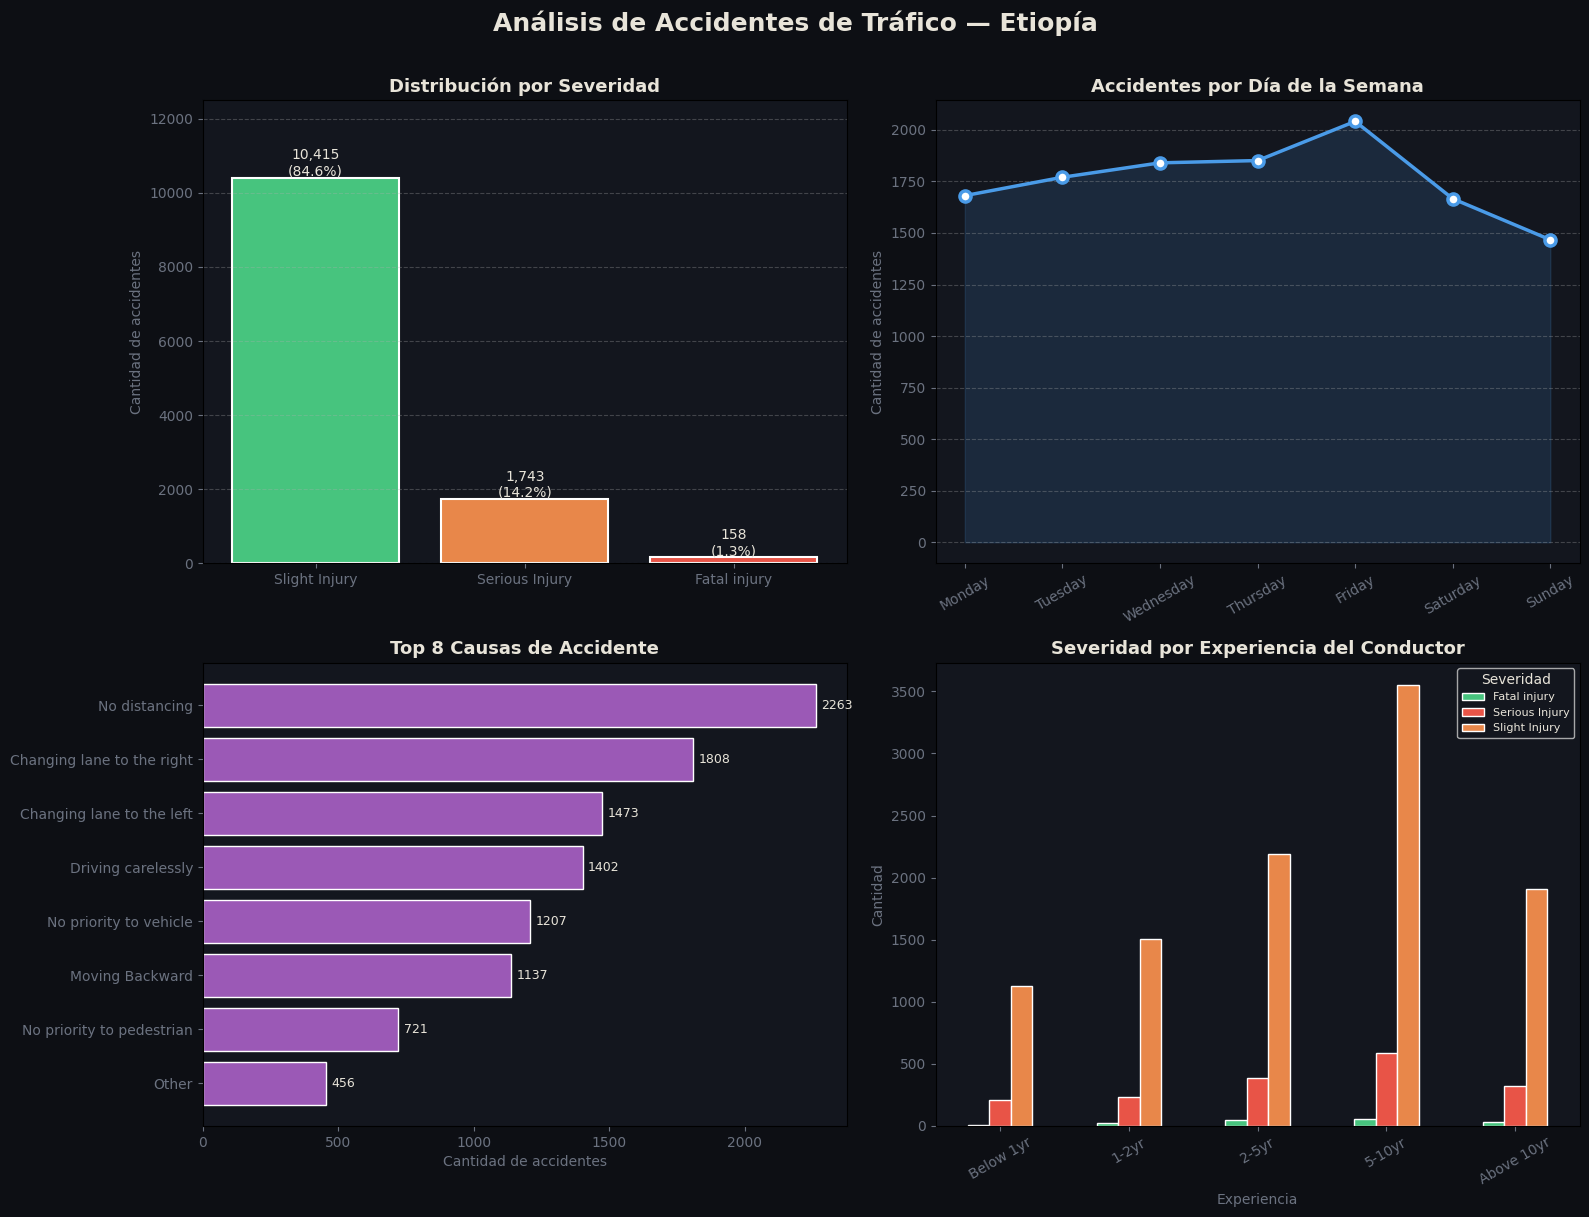

✅ Gráfico Fase 1 guardado


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis de Accidentes de Tráfico — Etiopía',
             fontsize=18, fontweight='bold', color='#e8e4d9', y=1.01)

# 1. Severidad
ax1 = axes[0, 0]
severity_counts = df['Accident_severity'].value_counts()
colors = ['#47c47e', '#e8874a', '#e85447']
bars = ax1.bar(severity_counts.index, severity_counts.values,
               color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Distribución por Severidad', fontsize=13, fontweight='bold')
ax1.set_ylabel('Cantidad de accidentes')
for bar, val in zip(bars, severity_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax1.set_ylim(0, severity_counts.max() * 1.2)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# 2. Día de la semana
ax2 = axes[0, 1]
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df['Day_of_week'].value_counts().reindex(orden_dias)
ax2.plot(orden_dias, day_counts.values, marker='o', color='#4a9be8',
         linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2.5)
ax2.fill_between(orden_dias, day_counts.values, alpha=0.15, color='#4a9be8')
ax2.set_title('Accidentes por Día de la Semana', fontsize=13, fontweight='bold')
ax2.set_ylabel('Cantidad de accidentes')
ax2.tick_params(axis='x', rotation=30)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# 3. Top 8 causas
ax3 = axes[1, 0]
top_causas = df['Cause_of_accident'].value_counts().head(8)
ax3.barh(top_causas.index[::-1], top_causas.values[::-1],
         color='#9b59b6', edgecolor='white')
ax3.set_title('Top 8 Causas de Accidente', fontsize=13, fontweight='bold')
ax3.set_xlabel('Cantidad de accidentes')
for i, val in enumerate(top_causas.values[::-1]):
    ax3.text(val + 20, i, str(val), va='center', fontsize=9)

# 4. Severidad por experiencia
ax4 = axes[1, 1]
exp_sev = df.groupby(['Driving_experience', 'Accident_severity']).size().unstack(fill_value=0)
exp_order = ['Below 1yr', '1-2yr', '2-5yr', '5-10yr', 'Above 10yr']
exp_sev = exp_sev.reindex([e for e in exp_order if e in exp_sev.index])
exp_sev.plot(kind='bar', ax=ax4, color=['#47c47e', '#e85447', '#e8874a'],
             edgecolor='white', linewidth=1)
ax4.set_title('Severidad por Experiencia del Conductor', fontsize=13, fontweight='bold')
ax4.set_xlabel('Experiencia')
ax4.set_ylabel('Cantidad')
ax4.tick_params(axis='x', rotation=30)
ax4.legend(title='Severidad', fontsize=8)

plt.tight_layout()
plt.savefig('analisis_fase1.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico Fase 1 guardado')

---
## 5. 🧪 Prueba Estadística — Chi-square Test

**Pregunta:** ¿La diferencia en letalidad entre Lunes y Domingo es real o casualidad?

> 💡 **P-value:** Probabilidad de que el patrón observado sea pura casualidad.  
> Si p < 0.05 → el patrón es **estadísticamente significativo**.

In [6]:
# Análisis de % fatal por día
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df.groupby(['Day_of_week', 'Accident_severity']).size().unstack(fill_value=0)
pivot = pivot.reindex(orden_dias)
pivot['%_Fatal']   = (pivot['Fatal injury'] / pivot.sum(axis=1) * 100).round(2)
pivot['%_Serious'] = (pivot['Serious Injury'] / pivot.sum(axis=1) * 100).round(2)

print('=== Severidad por día de la semana ===')
print(pivot[['Fatal injury', 'Serious Injury', 'Slight Injury', '%_Fatal', '%_Serious']])

# Chi-square: Lunes vs Domingo
tabla = pd.crosstab(
    df[df['Day_of_week'].isin(['Monday', 'Sunday'])]['Day_of_week'],
    df[df['Day_of_week'].isin(['Monday', 'Sunday'])]['Accident_severity']
)

chi2, p_value, dof, expected = stats.chi2_contingency(tabla)

print(f'\n=== Chi-square Test: Lunes vs Domingo ===')
print(f'Chi2:    {chi2:.4f}')
print(f'P-value: {p_value:.4f}')
print(f'\n{"✅ ESTADÍSTICAMENTE SIGNIFICATIVO" if p_value < 0.05 else "❌ No significativo"}')
print(f'{"→ La diferencia NO es casualidad (99.96% confianza)" if p_value < 0.05 else ""}')

=== Severidad por día de la semana ===
Accident_severity  Fatal injury  Serious Injury  Slight Injury  %_Fatal  \
Day_of_week                                                               
Monday                       12             204           1465     0.71   
Tuesday                      17             257           1496     0.96   
Wednesday                    19             262           1559     1.03   
Thursday                     22             272           1557     1.19   
Friday                       16             313           1712     0.78   
Saturday                     37             245           1384     2.22   
Sunday                       35             190           1242     2.39   

Accident_severity  %_Serious  
Day_of_week                   
Monday                 12.13  
Tuesday                14.51  
Wednesday              14.23  
Thursday               14.69  
Friday                 15.33  
Saturday               14.69  
Sunday                 12.93  

=== C

---
## 6. 🕐 Análisis Temporal — Fase 2

Extraemos la hora del día y clasificamos en franjas horarias para cruzar con severidad y día.

In [7]:
# Extraer hora desde columna Time
# pd.to_datetime() convierte el string a objeto de tiempo real
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

# Clasificar en franjas horarias
def franja(h):
    if 0 <= h < 6:     return 'Madrugada'
    elif 6 <= h < 12:  return 'Mañana'
    elif 12 <= h < 18: return 'Tarde'
    else:               return 'Noche'

df['Franja'] = df['Hour'].apply(franja)

# Clasificar tipo de día
df['Tipo_dia'] = df['Day_of_week'].apply(
    lambda x: 'Fin de semana' if x in ['Saturday', 'Sunday'] else 'Día laboral'
)

# Resumen por franja
print('=== Accidentes por franja horaria ===')
print(df['Franja'].value_counts())

print('\n=== % Fatal por franja ===')
for franja_nombre in ['Madrugada', 'Mañana', 'Tarde', 'Noche']:
    sub = df[df['Franja'] == franja_nombre]
    pct = (sub['Accident_severity'] == 'Fatal injury').mean() * 100
    print(f'{franja_nombre:12}: {pct:.2f}%')

=== Accidentes por franja horaria ===
Franja
Tarde        5125
Noche        3280
Mañana       3236
Madrugada     675
Name: count, dtype: int64

=== % Fatal por franja ===
Madrugada   : 2.52%
Mañana      : 0.77%
Tarde       : 1.01%
Noche       : 1.95%


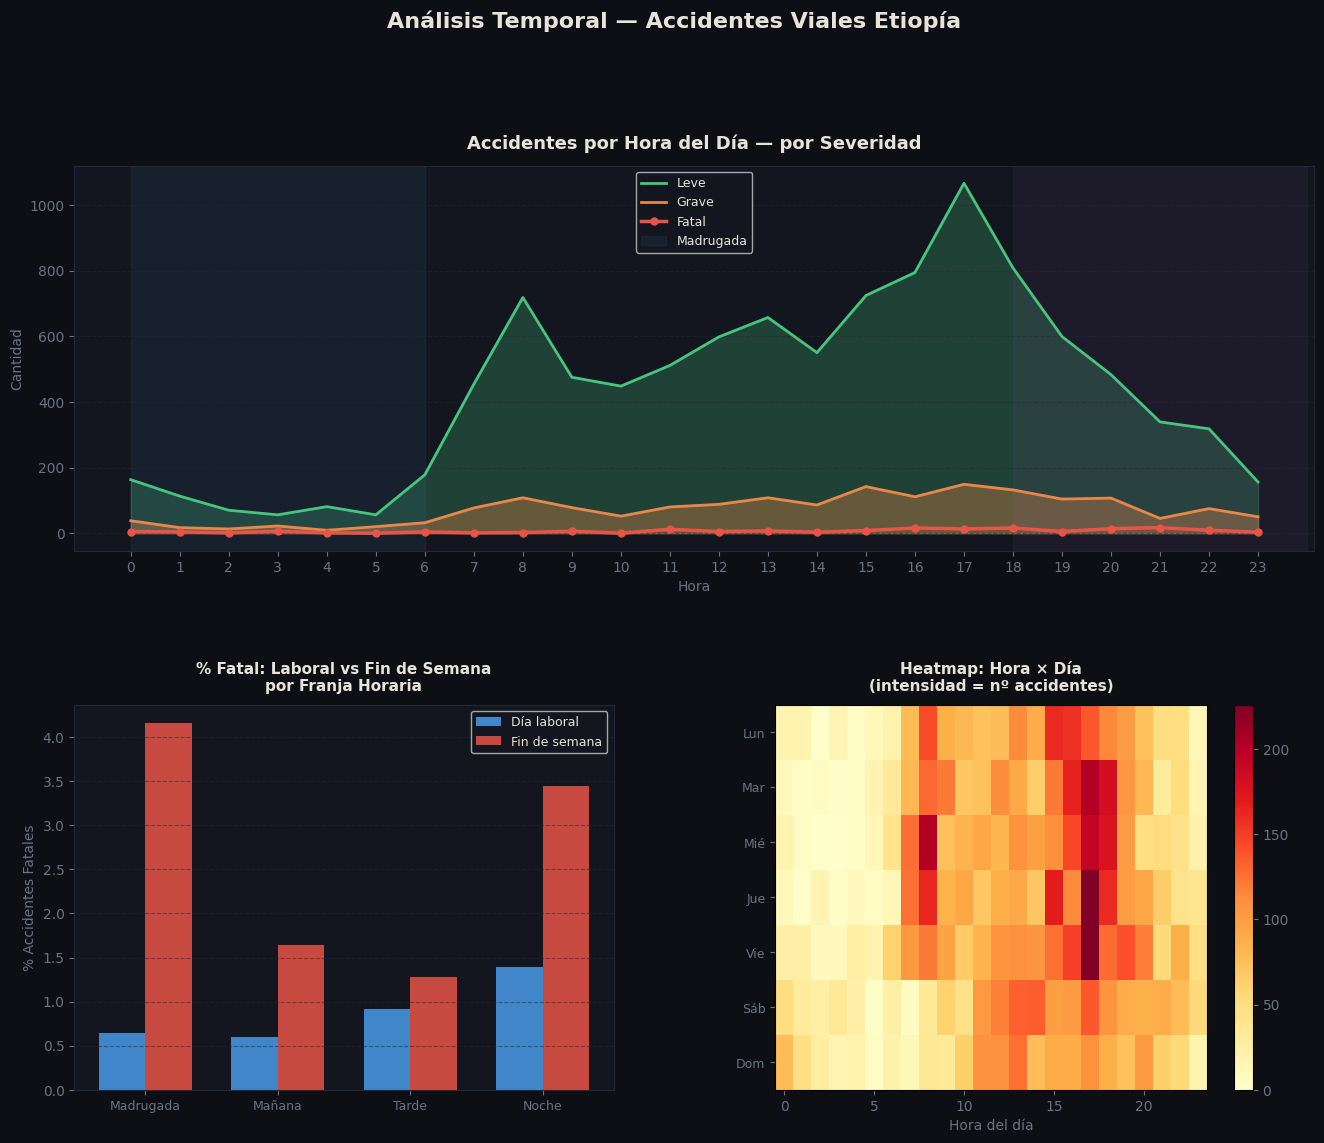

✅ Gráfico Fase 2 guardado


In [8]:
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#0d0f14')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

color_bg   = '#0d0f14'
color_card = '#13161e'
color_text = '#e8e4d9'
color_muted = '#6b7280'

# 1. Accidentes por hora
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(color_card)
hora_sev = df.groupby(['Hour', 'Accident_severity']).size().unstack(fill_value=0)
ax1.fill_between(hora_sev.index, hora_sev['Slight Injury'], alpha=0.25, color='#47c47e')
ax1.plot(hora_sev.index, hora_sev['Slight Injury'],
         color='#47c47e', linewidth=2, label='Leve')
ax1.fill_between(hora_sev.index, hora_sev['Serious Injury'], alpha=0.35, color='#e8874a')
ax1.plot(hora_sev.index, hora_sev['Serious Injury'],
         color='#e8874a', linewidth=2, label='Grave')
ax1.plot(hora_sev.index, hora_sev['Fatal injury'],
         color='#e85447', linewidth=2.5, marker='o', markersize=5, label='Fatal', zorder=5)
ax1.axvspan(0, 6, alpha=0.08, color='#4a9be8', label='Madrugada')
ax1.axvspan(18, 24, alpha=0.08, color='#9b59b6')
ax1.set_title('Accidentes por Hora del Día — por Severidad',
              color=color_text, fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Hora', color=color_muted)
ax1.set_ylabel('Cantidad', color=color_muted)
ax1.set_xticks(range(0, 24))
ax1.legend(facecolor=color_card, labelcolor=color_text, fontsize=9)
ax1.spines[['top','right','left','bottom']].set_color('#242836')
ax1.grid(axis='y', color='#242836', linestyle='--', alpha=0.5)

# 2. % Fatal por franja: laboral vs fin de semana
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(color_card)
orden_franja = ['Madrugada', 'Mañana', 'Tarde', 'Noche']
pivot_ft = df.groupby(['Franja', 'Tipo_dia', 'Accident_severity']).size().unstack(fill_value=0)
pivot_ft['pct_fatal'] = (pivot_ft['Fatal injury'] / pivot_ft.sum(axis=1) * 100).round(2)
pct = pivot_ft['pct_fatal'].unstack('Tipo_dia').reindex(orden_franja)
x = np.arange(len(orden_franja))
w = 0.35
ax2.bar(x - w/2, pct['Día laboral'],   w, label='Día laboral',   color='#4a9be8', alpha=0.85)
ax2.bar(x + w/2, pct['Fin de semana'], w, label='Fin de semana', color='#e85447', alpha=0.85)
ax2.set_title('% Fatal: Laboral vs Fin de Semana\npor Franja Horaria',
              color=color_text, fontsize=11, fontweight='bold', pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(orden_franja, color=color_muted, fontsize=9)
ax2.set_ylabel('% Accidentes Fatales', color=color_muted)
ax2.legend(facecolor=color_card, labelcolor=color_text, fontsize=9)
ax2.spines[['top','right','left','bottom']].set_color('#242836')
ax2.grid(axis='y', color='#242836', linestyle='--', alpha=0.5)

# 3. Heatmap hora x día
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(color_card)
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dias_es    = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
heat = df.groupby(['Day_of_week', 'Hour']).size().unstack(fill_value=0).reindex(orden_dias)
im = ax3.imshow(heat.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax3.set_title('Heatmap: Hora × Día\n(intensidad = nº accidentes)',
              color=color_text, fontsize=11, fontweight='bold', pad=10)
ax3.set_yticks(range(7))
ax3.set_yticklabels(dias_es, color=color_muted, fontsize=9)
ax3.set_xlabel('Hora del día', color=color_muted)
plt.colorbar(im, ax=ax3).ax.tick_params(colors=color_muted)

fig.suptitle('Análisis Temporal — Accidentes Viales Etiopía',
             color=color_text, fontsize=16, fontweight='bold', y=1.01)

plt.savefig('analisis_temporal.png', dpi=150, bbox_inches='tight', facecolor=color_bg)
plt.show()
print('✅ Gráfico Fase 2 guardado')

---
## 7. 💡 Conclusiones

### Hallazgos estadísticamente validados

| # | Hallazgo | Evidencia |
|---|---|---|
| 1 | El domingo tiene 3× más accidentes fatales que el lunes | p=0.0004 (chi-square) |
| 2 | La madrugada del fin de semana es 7× más letal que la laboral | 4.1% vs 0.6% |
| 3 | No distancing es la causa principal con 2,263 casos | 18.4% del total |
| 4 | Conductores de 5-10 años concentran más accidentes (paradoja de confianza) | Análisis descriptivo |
| 5 | El pico de volumen es 17h, pero no coincide con el pico de letalidad | Análisis temporal |

### Recomendación accionable
> *"Las políticas de seguridad vial deberían enfocarse en controles nocturnos de fin de semana, no solo en gestionar el tráfico de hora pico. Un conductor tiene 7 veces más probabilidad de morir en la madrugada del fin de semana que en un día laboral normal."*